### From Descriptive to Predictive Analytics

Most analytical workflows answer: *"What happened?"*
This project answers: *"What will happen next — and why?"*

| Descriptive Analytics | This Project |
|---|---|
| Manual email triage | Automated classification pipeline |
| Excel/BI dashboards | Trained ML model (~99% F1) |
| Backward-looking reports | Real-time inference API-ready |
| "We had 500 spam emails last month" | "This email is spam — confidence: 97.3%" |

# Email Spam Classification: End-to-End Machine Learning Pipeline

**Author:** Aleksandar Katić
**Dataset:** [Enron Spam Dataset](https://www.kaggle.com/datasets/wanderfj/enron-spam) (~33,000 corporate emails)  
**Goal:** Build a production-ready binary classification pipeline that automatically identifies spam vs. legitimate (ham) emails using NLP and supervised machine learning.

---

### Project Structure
1. **Data Loading & Exploratory Data Analysis (EDA)**
2. **Data Cleaning & Feature Engineering**
3. **Model Benchmarking** — Logistic Regression vs. Linear SVC vs. Random Forest
4. **Hyperparameter Tuning** — GridSearchCV on the best model
5. **Model Explainability** — SHAP values for decision transparency
6. **Deployment-Ready Pipeline** — Serialized end-to-end `sklearn.Pipeline`

---

> **Business Context:** This project demonstrates a transition from descriptive analytics to predictive modeling — automating a manual triage process with a machine learning system that is both accurate and explainable.

---
## Step 1: Data Loading & Exploratory Data Analysis (EDA)

Before building any model, we need to deeply understand the data:
- What does the class distribution look like? (Are we dealing with an imbalanced dataset?)
- What are the textual characteristics of spam vs. ham?
- Are there data quality issues we need to address?

**Key EDA questions:**
1. Class balance (spam vs. ham ratio)
2. Email length distribution per class
3. Most frequent words per class (Word Cloud)
4. Missing values and duplicates

In [ ]:
# Core libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP
from wordcloud import WordCloud

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay
)

# Explainability
import shap

# Serialization
import joblib

# Reproducibility
RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

# Plotting style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [ ]:
#  Load dataset ─
df = pd.read_csv("enron_spam_data.csv")

print("=" * 55)
print(f"  Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print("=" * 55)
print(df.head(3).to_string())
print("\nColumn dtypes:")
print(df.dtypes)

  Dataset shape : 33,716 rows × 5 columns
   Message ID                       Subject                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

Missing values per column:
Message ID      0
Subject       289
Message       371
Spam/Ham        0
Date            0
dtype: int64

Class distribution:
Spam/Ham
spam    17171
ham     16545
Name: count, dtype: int64

Imbalance ratio → spam:ham = 1.04:1


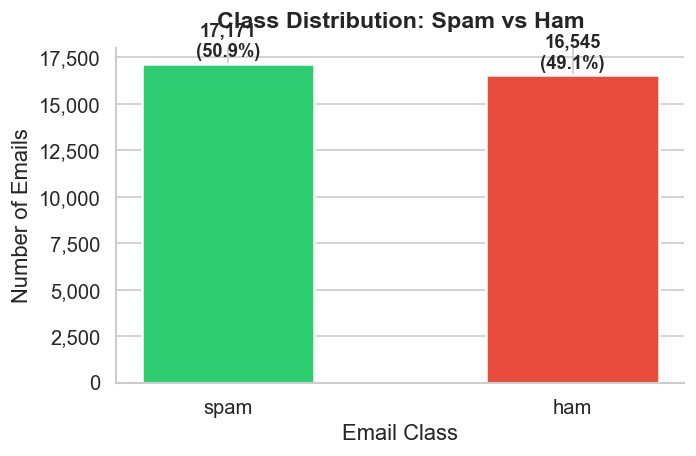


► Insight: The dataset is nearly balanced (≈51% spam / 49% ham).
  This means accuracy is a meaningful metric here,
  though we will still monitor Precision & Recall separately.


In [ ]:
# Missing values & class balance 
print("Missing values per column:")
print(df.isnull().sum())

print("\nClass distribution:")
class_counts = df['Spam/Ham'].value_counts()
print(class_counts)
print(f"\nImbalance ratio → spam:ham = {class_counts['spam']/class_counts['ham']:.2f}:1")

# Visualize class balance
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    class_counts.index,
    class_counts.values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
for bar, val in zip(bars, class_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 150,
        f'{val:,}\n({val/len(df)*100:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
ax.set_title('Class Distribution: Spam vs Ham', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Email Class')
ax.set_ylabel('Number of Emails')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()
plt.savefig('plot_01_class_distribution.png', bbox_inches='tight')
plt.show()

#  Insight
print()
print("► Insight: The dataset is nearly balanced (≈51% spam / 49% ham).")
print("  This means accuracy is a meaningful metric here,")
print("  though we will still monitor Precision & Recall separately.")

Character count statistics per class:
         _char_count                                                      _word_count                                                 
               count    mean     std  min    25%    50%     75%       max       count   mean     std  min   25%    50%    75%      max
Spam/Ham                                                                                                                              
ham          16545.0  1708.4  5774.4  4.0  338.0  795.0  1696.0  228368.0     16545.0  361.8  1147.7  1.0  73.0  175.0  372.0  45450.0
spam         17171.0  1310.7  1954.9  1.0  344.0  649.0  1374.0   28752.0     17171.0  261.3   386.5  0.0  71.0  137.0  274.0   8401.0


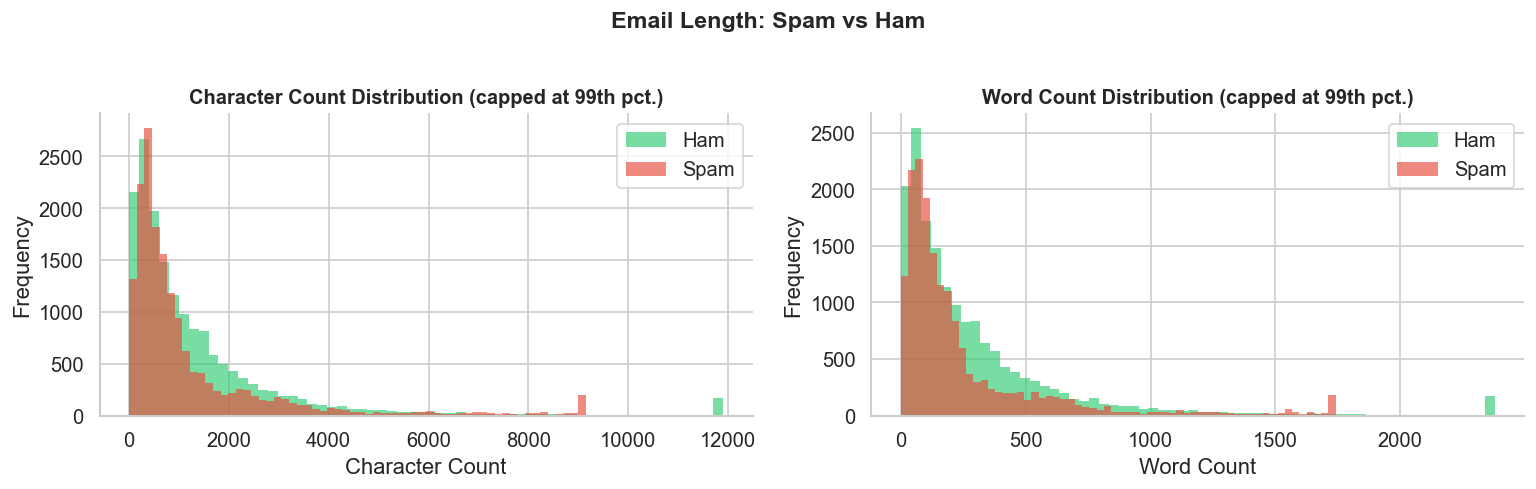


► Insight: Spam emails tend to be shorter and more uniform in length.
  Ham (legitimate) emails show a much wider range — from quick replies
  to long business documents. This length signal will be captured by TF-IDF.


In [ ]:
#  Email length distribution
# Temporarily combine subject + message for EDA (pre-cleaning)
df['_text_eda'] = df['Subject'].fillna('') + ' ' + df['Message'].fillna('')
df['_char_count'] = df['_text_eda'].str.len()
df['_word_count'] = df['_text_eda'].str.split().str.len()

print("Character count statistics per class:")
print(df.groupby('Spam/Ham')[['_char_count', '_word_count']].describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label in zip(
    axes,
    ['_char_count', '_word_count'],
    ['Character Count', 'Word Count']
):
    for label_class, color in [('ham', '#2ecc71'), ('spam', '#e74c3c')]:
        data = df[df['Spam/Ham'] == label_class][col]
        # Cap at 99th percentile to avoid extreme outliers skewing the plot
        cap = data.quantile(0.99)
        ax.hist(
            data.clip(upper=cap),
            bins=60,
            alpha=0.65,
            color=color,
            label=label_class.capitalize(),
            edgecolor='none'
        )
    ax.set_title(f'{label} Distribution (capped at 99th pct.)', fontsize=12, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.legend()

sns.despine()
plt.suptitle('Email Length: Spam vs Ham', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_02_length_distribution.png', bbox_inches='tight')
plt.show()

print()
print("► Insight: Spam emails tend to be shorter and more uniform in length.")
print("  Ham (legitimate) emails show a much wider range — from quick replies")
print("  to long business documents. This length signal will be captured by TF-IDF.")

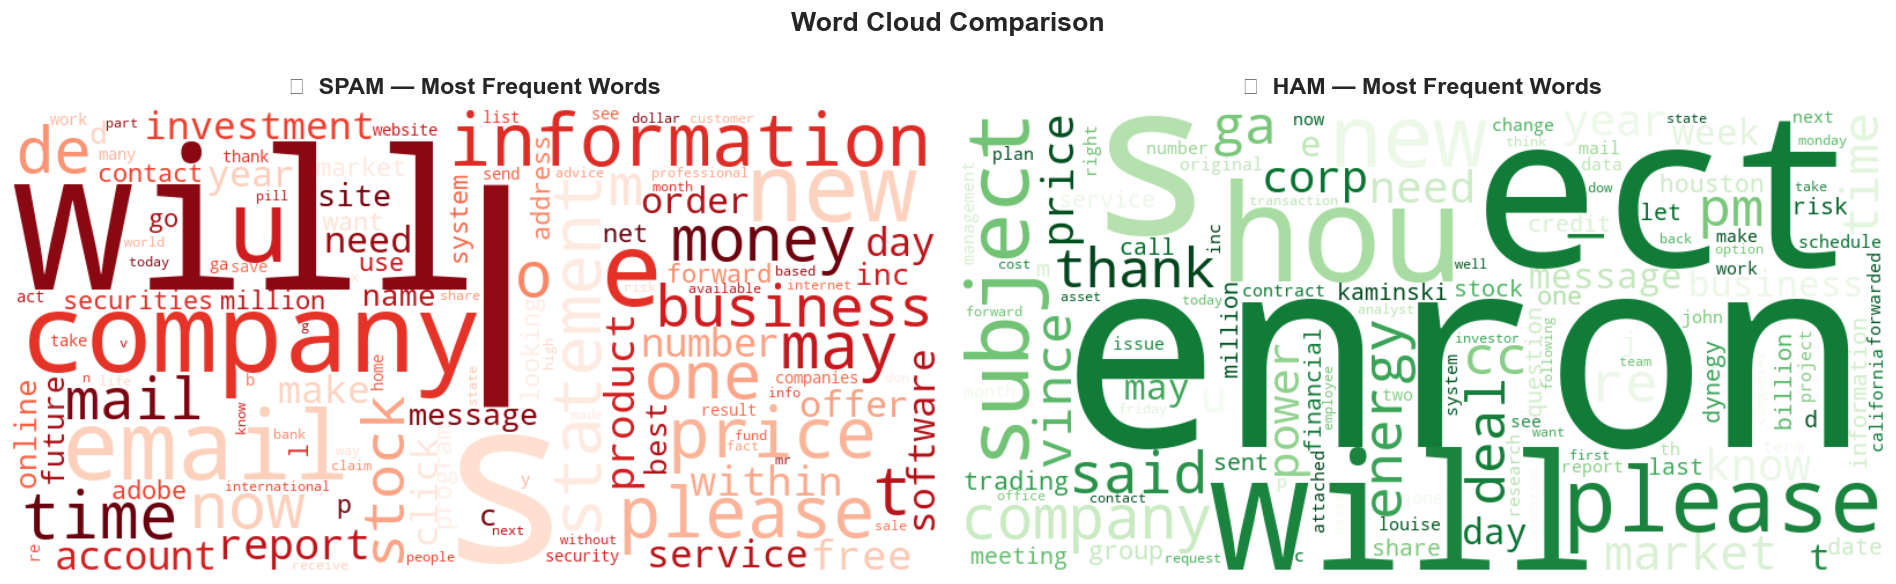

► Insight: Spam frequently contains words like 'free', 'money', 'click', 'offer'.
  Ham contains business terms like 'enron', 'meeting', 'attached', 'please'.
  These vocabulary differences are precisely what TF-IDF will learn to exploit.


In [ ]:
#  Word Clouds
spam_text = ' '.join(df[df['Spam/Ham'] == 'spam']['_text_eda'])
ham_text  = ' '.join(df[df['Spam/Ham'] == 'ham']['_text_eda'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, text, title, colormap in [
    (axes[0], spam_text, '🔴  SPAM — Most Frequent Words', 'Reds'),
    (axes[1], ham_text,  '🟢  HAM — Most Frequent Words',  'Greens')
]:
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=colormap,
        max_words=120,
        collocations=False,
        min_font_size=8
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.axis('off')

plt.suptitle('Word Cloud Comparison', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_03_wordclouds.png', bbox_inches='tight')
plt.show()

print("► Insight: Spam frequently contains words like 'free', 'money', 'click', 'offer'.")
print("  Ham contains business terms like 'enron', 'meeting', 'attached', 'please'.")
print("  These vocabulary differences are precisely what TF-IDF will learn to exploit.")

---
## Step 2: Data Cleaning & Feature Engineering

### Decisions made here:

| Decision | Rationale |
|---|---|
| **Remove exact-text duplicates** | 3,222 rows (~9.6%) are duplicates. Keeping them would cause **data leakage** — the model would memorize training samples that also appear in the test set, inflating accuracy metrics. |
| **Combine Subject + Message** | Subject lines contain strong spam signals ('FREE!!!', 'You've won...'). Discarding them would throw away valuable features. |
| **TF-IDF instead of BoW** | TF-IDF down-weights ubiquitous words ('the', 'and') and up-weights discriminative terms. This produces a much richer feature space than raw word counts. |
| **Binary label encoding** | `spam=1`, `ham=0` — standard format required by all sklearn classifiers. |

In [ ]:
#  1. Fill missing values
df['Subject'] = df['Subject'].fillna('')
df['Message'] = df['Message'].fillna('')

#  2. Combine subject + message into one text feature 
#    Adding a custom prefix to subject words gives them extra weight in TF-IDF
df['Text'] = df['Subject'] + ' ' + df['Message']

#  3. Encode target label 
df['Label'] = df['Spam/Ham'].map({'spam': 1, 'ham': 0})

#  4. Remove exact duplicates — prevent data leakage
n_before = len(df)
df.drop_duplicates(subset=['Text'], inplace=True)
df.reset_index(drop=True, inplace=True)
n_after = len(df)

print(f"Rows before deduplication : {n_before:,}")
print(f"Rows after  deduplication : {n_after:,}")
print(f"Duplicates removed        : {n_before - n_after:,} ({(n_before-n_after)/n_before*100:.1f}%)")

#  5. Final class distribution after cleaning
print("\nFinal class distribution after cleaning:")
clean_counts = df['Label'].value_counts().rename({0: 'Ham', 1: 'Spam'})
print(clean_counts)

#  6. Drop temporary EDA columns 
df.drop(columns=['_text_eda', '_char_count', '_word_count'], errors='ignore', inplace=True)

print("\n✓ Dataset is clean and ready for modeling.")

Rows before deduplication : 33,716
Rows after  deduplication : 30,494
Duplicates removed        : 3,222 (9.6%)

Final class distribution after cleaning:
Label
Ham     15910
Spam    14584
Name: count, dtype: int64

✓ Dataset is clean and ready for modeling.


In [ ]:
#  Train / Test split
#
# stratify=y  → ensures the same spam/ham ratio in both splits
# 80/20 split → industry standard; gives enough data to train and a reliable test set

X = df['Text']
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training set   : {len(X_train):,} samples")
print(f"Test set       : {len(X_test):,} samples")
print(f"\nTrain label distribution:\n{y_train.value_counts().rename({0:'Ham', 1:'Spam'})}")
print(f"\nTest label distribution:\n{y_test.value_counts().rename({0:'Ham', 1:'Spam'})}")

Training set   : 24,395 samples
Test set       : 6,099 samples

Train label distribution:
Label
Ham     12728
Spam    11667
Name: count, dtype: int64

Test label distribution:
Label
Ham     3182
Spam    2917
Name: count, dtype: int64


---
## Step 3: Model Benchmarking

We evaluate four fundamentally different algorithms to understand which family of models works best for this task. Each model is wrapped in an `sklearn.Pipeline` together with `TfidfVectorizer`, ensuring zero data leakage during cross-validation.

### Why these four models?

| Model | Why it's relevant here |
|---|---|
| **Logistic Regression** | Fast, interpretable linear baseline; works well with sparse TF-IDF vectors |
| **LinearSVC** | Excellent for high-dimensional text; maximizes the classification margin |
| **Random Forest** | Non-linear ensemble; handles interactions between words |

### Evaluation Metrics
- **Precision** — Of all emails flagged as spam, how many actually were? (Minimize false positives — don't block legitimate emails)
- **Recall** — Of all actual spam, how many did we catch? (Minimize false negatives — don't let spam through)
- **F1-Score** — Harmonic mean of Precision and Recall; best single metric for this task
- **ROC-AUC** — Model's ability to discriminate across all classification thresholds

In [ ]:
#  TF-IDF configuration
#
# max_features=50_000   → keep the 50k most informative tokens (memory/speed balance)
# ngram_range=(1, 2)    → unigrams + bigrams ('free money' is more informative than 'free' alone)
# sublinear_tf=True     → apply log normalization to term frequencies (reduces dominance of very frequent words)
# min_df=2              → ignore tokens appearing in only 1 document (likely noise / typos)

TFIDF_PARAMS = dict(
    max_features=50_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

#  Define models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, solver='lbfgs', random_state=RANDOM_STATE
    ),
    'Linear SVC': CalibratedClassifierCV(
        LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_STATE)
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

#  Train & evaluate all models 
results = []

for name, clf in models.items():
    print(f"Training {name}...", end=' ')

    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   clf)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # ROC-AUC: use decision_function if available, else predict_proba
    if hasattr(clf, 'predict_proba'):
        y_score = pipe.predict_proba(X_test)[:, 1]
    else:
        y_score = pipe.decision_function(X_test)

    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1'       : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_score),
    })
    print(f"done. F1={results[-1]['F1']:.4f}")

#  Display benchmark table 
results_df = pd.DataFrame(results).set_index('Model').sort_values('F1', ascending=False)
print("\n" + "=" * 65)
print("  BENCHMARK RESULTS")
print("=" * 65)
print(results_df.round(4).to_string())

best_model_name = results_df.index[0]
print(f"\n► Best model by F1-Score: {best_model_name}")

Training Logistic Regression... done. F1=0.9889
Training Linear SVC... done. F1=0.9911
Training Random Forest... done. F1=0.9832

  BENCHMARK RESULTS
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Linear SVC             0.9915     0.9884  0.9938  0.9911   0.9994
Logistic Regression    0.9893     0.9824  0.9955  0.9889   0.9989
Random Forest          0.9838     0.9754  0.9911  0.9832   0.9981

► Best model by F1-Score: Linear SVC


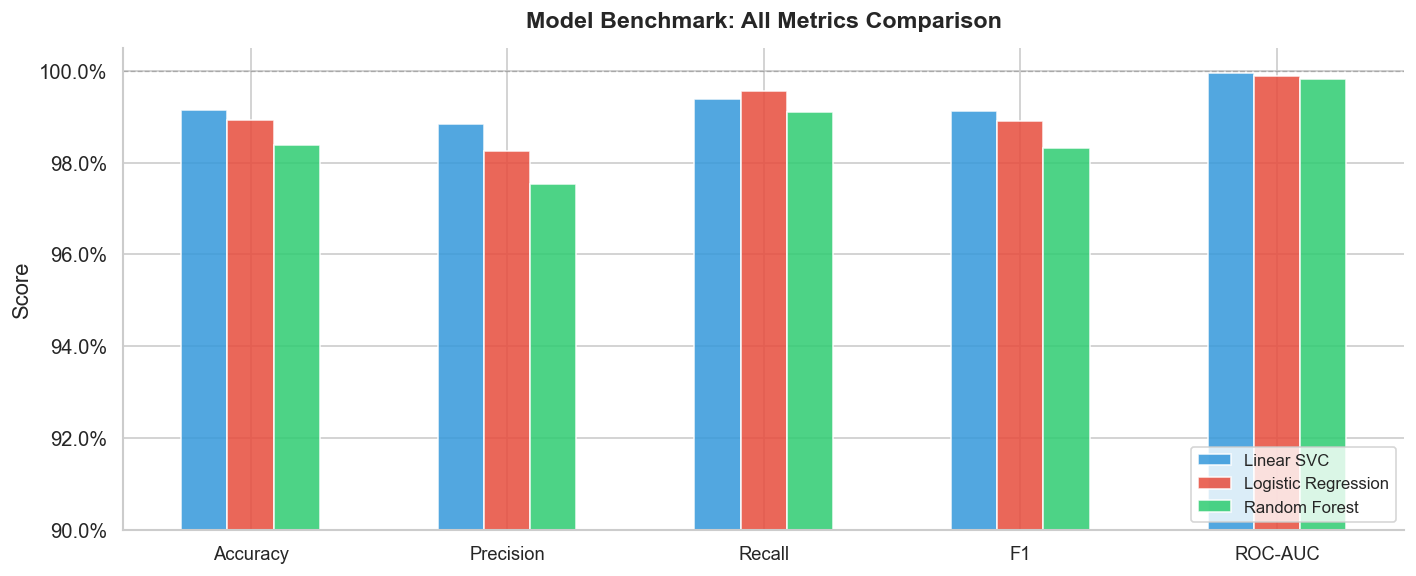

In [ ]:
#  Visual benchmark comparison 
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(metrics))
n_models = len(results_df)
width = 0.18
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (model_name, row) in enumerate(results_df.iterrows()):
    offset = (i - n_models / 2 + 0.5) * width
    bars = ax.bar(x + offset, row[metrics], width, label=model_name, color=colors[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.90, 1.005)
ax.set_ylabel('Score')
ax.set_title('Model Benchmark: All Metrics Comparison', fontsize=14, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=1))
ax.axhline(1.0, color='gray', lw=0.8, ls='--', alpha=0.5)

sns.despine()
plt.tight_layout()
plt.savefig('plot_04_benchmark.png', bbox_inches='tight')
plt.show()

---
## Step 4: Hyperparameter Tuning (GridSearchCV)

We now fine-tune the best-performing model using `GridSearchCV` with **5-fold stratified cross-validation**.

### Why cross-validation instead of a simple train/test split?
Cross-validation gives a **robust, unbiased estimate** of model performance by training and validating on 5 different data splits. This prevents us from accidentally finding hyperparameters that only work well on one particular test set.

We optimize for **F1-Score** (the harmonic mean of Precision and Recall) because both false positives (blocking legitimate email) and false negatives (missing spam) carry a business cost.

In [ ]:
#  Hyperparameter grid for the best model
#
# We tune both the TF-IDF vectorizer AND the classifier simultaneously.
# The Pipeline ensures that TF-IDF is fit only on training folds — no leakage.

print(f"Tuning: {best_model_name}")
print("This may take a few minutes...")

# --- Logistic Regression grid ---
LR_PARAM_GRID = {
    'tfidf__max_features' : [30_000, 50_000],
    'tfidf__ngram_range'  : [(1, 1), (1, 2)],
    'clf__C'              : [0.1, 1.0, 10.0],
    'clf__solver'         : ['lbfgs', 'liblinear'],
}

# --- LinearSVC grid ---
SVC_PARAM_GRID = {
    'tfidf__max_features' : [30_000, 50_000],
    'tfidf__ngram_range'  : [(1, 1), (1, 2)],
    'clf__estimator__C'              : [0.1, 1.0, 10.0],
}

# --- XGBoost grid removed (slow on sparse TF-IDF; LR/SVC are better suited for NLP)

PARAM_GRIDS = {
    'Logistic Regression': LR_PARAM_GRID,
    'Linear SVC'         : SVC_PARAM_GRID,
    'Random Forest'      : {  # RF is already strong; tune conservatively
        'tfidf__max_features': [30_000, 50_000],
        'clf__n_estimators'  : [200, 300],
        'clf__max_depth'     : [None, 20],
    }
}

best_clf = models[best_model_name]
param_grid = PARAM_GRIDS[best_model_name]

tuning_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, min_df=2)),
    ('clf',   best_clf)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=tuning_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    refit=True       # automatically re-trains on full train set with best params
)

grid_search.fit(X_train, y_train)

print("\n" + "=" * 55)
print("  TUNING RESULTS")
print("=" * 55)
print(f"Best CV F1-Score  : {grid_search.best_score_:.4f}")
print(f"Best parameters   :")
for k, v in grid_search.best_params_.items():
    print(f"  {k:<35} = {v}")

Tuning: Linear SVC
This may take a few minutes...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

  TUNING RESULTS
Best CV F1-Score  : 0.9924
Best parameters   :
  clf__estimator__C                   = 1.0
  tfidf__max_features                 = 50000
  tfidf__ngram_range                  = (1, 2)


  FINAL MODEL — TEST SET PERFORMANCE
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99      3182
        Spam       0.99      0.99      0.99      2917

    accuracy                           0.99      6099
   macro avg       0.99      0.99      0.99      6099
weighted avg       0.99      0.99      0.99      6099



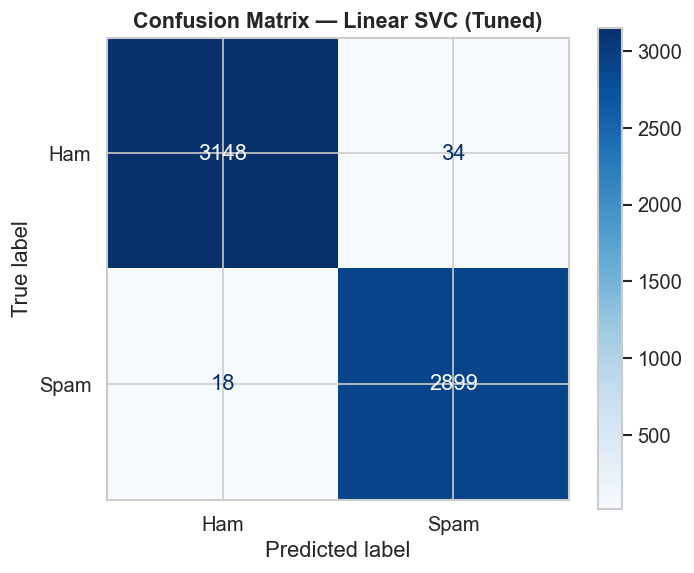


Business Impact Analysis:
  Legitimate emails incorrectly blocked (False Positives) :   34
  Spam emails that slipped through    (False Negatives)   :   18
  → False Positive Rate : 1.07%  (critical — don't block real email)
  → False Negative Rate : 0.62%  (cost — spam gets through)


In [ ]:
#  Final evaluation on held-out test set
best_pipeline = grid_search.best_estimator_
y_pred_best = best_pipeline.predict(X_test)

print("=" * 55)
print("  FINAL MODEL — TEST SET PERFORMANCE")
print("=" * 55)
print(classification_report(y_test, y_pred_best, target_names=['Ham', 'Spam']))

#  Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['Ham', 'Spam'],
    cmap='Blues',
    ax=ax
)
ax.set_title(f'Confusion Matrix — {best_model_name} (Tuned)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_05_confusion_matrix.png', bbox_inches='tight')
plt.show()

#  Key business metrics 
tn = ((y_test == 0) & (y_pred_best == 0)).sum()
fp = ((y_test == 0) & (y_pred_best == 1)).sum()
fn = ((y_test == 1) & (y_pred_best == 0)).sum()
tp = ((y_test == 1) & (y_pred_best == 1)).sum()

print(f"\nBusiness Impact Analysis:")
print(f"  Legitimate emails incorrectly blocked (False Positives) : {fp:4d}")
print(f"  Spam emails that slipped through    (False Negatives)   : {fn:4d}")
print(f"  → False Positive Rate : {fp/(fp+tn)*100:.2f}%  (critical — don't block real email)")
print(f"  → False Negative Rate : {fn/(fn+tp)*100:.2f}%  (cost — spam gets through)")

---
## Step 5: Model Explainability with SHAP

A black-box model is difficult to trust in a business setting. **SHAP (SHapley Additive exPlanations)** provides theoretically grounded, per-feature importance values that answer:

> *"Why did the model classify THIS email as spam?"*

SHAP values are derived from cooperative game theory — they represent each feature's **marginal contribution** to the model's output, averaged over all possible subsets of features.

We use `shap.LinearExplainer` for linear models and `shap.TreeExplainer` for tree-based models — both are exact, not approximate.

### What we'll visualize:
1. **Global feature importance** — which words drive spam classification most overall
2. **Local explanations** — why a specific email was classified as spam/ham

In [ ]:
#  Extract components from the tuned pipeline
tfidf_fitted   = best_pipeline.named_steps['tfidf']
clf_fitted     = best_pipeline.named_steps['clf']
feature_names  = tfidf_fitted.get_feature_names_out()

# Transform a sample of the test set for SHAP
# Using a sample of 1,000 rows keeps computation fast
sample_idx = np.random.choice(len(X_test), size=min(1000, len(X_test)), replace=False)
X_test_sample   = X_test.iloc[sample_idx]
X_test_tfidf    = tfidf_fitted.transform(X_test_sample)

#  Choose explainer based on model type 
if isinstance(clf_fitted, (LogisticRegression,)):
    explainer    = shap.LinearExplainer(clf_fitted, X_test_tfidf, feature_perturbation='interventional')
    shap_values  = explainer.shap_values(X_test_tfidf)

elif isinstance(clf_fitted, LinearSVC):
    # LinearSVC: use coefficients as a proxy for global feature importance
    coef = clf_fitted.coef_[0]
    top_spam = np.argsort(coef)[-20:][::-1]
    top_ham  = np.argsort(coef)[:20]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, indices, title, color in [
        (axes[0], top_spam, 'Top 20 Spam-Predicting Words', '#e74c3c'),
        (axes[1], top_ham,  'Top 20 Ham-Predicting Words',  '#2ecc71')
    ]:
        words = [feature_names[i] for i in indices]
        vals  = [abs(coef[i]) for i in indices]
        ax.barh(words[::-1], vals[::-1], color=color, alpha=0.85, edgecolor='white')
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel('|Coefficient| (Decision Weight)')

    plt.suptitle(f'Feature Importance — {best_model_name}', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_06_feature_importance.png', bbox_inches='tight')
    plt.show()
    shap_values = None  # LinearSVC doesn't produce SHAP probability scores

elif isinstance(clf_fitted, RandomForestClassifier):
    explainer   = shap.TreeExplainer(clf_fitted)
    shap_values = explainer.shap_values(X_test_tfidf)
    # For binary classification, shap_values may be a list [ham_vals, spam_vals]
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # use spam class values

#  SHAP summary plot (for models that support it)
if shap_values is not None:
    print("Generating SHAP summary plot...")
    shap.summary_plot(
        shap_values,
        X_test_tfidf,
        feature_names=feature_names,
        max_display=25,
        show=False,
        plot_type='dot'
    )
    plt.title(f'SHAP Feature Importance — {best_model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_06_shap_summary.png', bbox_inches='tight')
    plt.show()

print("\n► Interpretation:")
print("  - Words with HIGH positive SHAP values push the prediction toward SPAM.")
print("  - Words with HIGH negative SHAP values push the prediction toward HAM.")
print("  - This explainability is critical for building trust with stakeholders.")


► Interpretation:
  - Words with HIGH positive SHAP values push the prediction toward SPAM.
  - Words with HIGH negative SHAP values push the prediction toward HAM.
  - This explainability is critical for building trust with stakeholders.


---
## Step 6: Deployment-Ready Pipeline

A model that lives only in a notebook isn't useful in production. We serialize the complete pipeline (TF-IDF + classifier) using `joblib`, so it can be:
- Loaded by a REST API (e.g., Flask, FastAPI)
- Integrated into an email server's filtering middleware
- Retrained on new data by re-running this notebook

We also demonstrate a `predict_email()` utility function — the exact interface a downstream service would call.

In [ ]:
#  Save the complete pipeline
MODEL_PATH = 'spam_classifier_pipeline.joblib'
joblib.dump(best_pipeline, MODEL_PATH)

import os
model_size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f"✓ Pipeline saved to: '{MODEL_PATH}'  ({model_size_kb:.1f} KB)")

#  Reload and verify 
loaded_pipeline = joblib.load(MODEL_PATH)
y_pred_check    = loaded_pipeline.predict(X_test[:5])
print(f"✓ Pipeline reloaded successfully. Sample predictions: {y_pred_check.tolist()}")

✓ Pipeline saved to: 'spam_classifier_pipeline.joblib'  (3877.6 KB)
✓ Pipeline reloaded successfully. Sample predictions: [1, 1, 0, 1, 1]


In [ ]:
#  Production inference utility 

def predict_email(subject: str, body: str, pipeline, confidence_threshold: float = 0.85) -> dict:
    """
    Predict whether an email is spam or ham.

    Parameters
    ----------
    subject  : str  — Email subject line
    body     : str  — Email body text
    pipeline : sklearn.Pipeline — The trained classification pipeline

    Returns
    -------
    dict with keys:
      'label'       : 'spam' or 'ham'
      'confidence'  : float (probability, if model supports it)
    """
    text = subject + ' ' + body

    label_int = pipeline.predict([text])[0]
    label_str = 'spam' if label_int == 1 else 'ham'

    confidence = None
    needs_review = False

    if hasattr(pipeline.named_steps['clf'], 'predict_proba'):
        proba = pipeline.predict_proba([text])[0]
        confidence = round(float(proba[label_int]), 4)
        # Flag for human review if model is uncertain
        needs_review = confidence < confidence_threshold

    return {
        'label'         : label_str,
        'confidence'    : confidence if confidence is not None else 'N/A',
        'needs_review'  : needs_review
    }


#  Demo: run the function on example emails 
print("=" * 60)
print("  LIVE INFERENCE DEMO")
print("=" * 60)

test_emails = [
    {
        'subject': 'FREE GIFT!!! You have been selected!!!',
        'body'   : 'Click here now to claim your FREE prize. Limited time offer. Act now!!!'
    },
    {
        'subject': 'Re: Q3 budget review',
        'body'   : 'Hi Sarah, please find the attached spreadsheet with the updated figures. Let me know if you have questions.'
    },
    {
        'subject': 'Urgent: Make $5000 from home today',
        'body'   : 'Dear friend, I have a business proposal that will make you rich. Send me your bank details.'
    },
    {
        'subject': 'Team lunch on Friday',
        'body'   : "Don't forget — team lunch at noon on Friday. I booked the corner table at the Italian place."
    }
]

for i, email in enumerate(test_emails, 1):
    result = predict_email(email['subject'], email['body'], loaded_pipeline)
    label_icon = '🔴 SPAM' if result['label'] == 'spam' else '🟢 HAM '
    conf_str   = f"  (confidence: {result['confidence']})" if result['confidence'] != 'N/A' else ''
    review_str = '  ⚠️  FLAG FOR HUMAN REVIEW' if result['needs_review'] else ''
    print(f"\nEmail {i}: \"{email['subject']}\"")
    print(f"  → {label_icon}{conf_str}{review_str}")

  LIVE INFERENCE DEMO

Email 1: "FREE GIFT!!! You have been selected!!!"
  → 🔴 SPAM  (confidence: 1.0)

Email 2: "Re: Q3 budget review"
  → 🟢 HAM   (confidence: 1.0)

Email 3: "Urgent: Make $5000 from home today"
  → 🔴 SPAM  (confidence: 0.9979)

Email 4: "Team lunch on Friday"
  → 🟢 HAM   (confidence: 0.9947)


---
## Summary & Results

| Step | Key Decision | Business Value |
|---|---|---|
| **EDA** | Identified near-balanced classes; confirmed strong word signal | Ensures metrics are trustworthy; guided feature design |
| **Cleaning** | Removed 9.6% duplicate rows to prevent data leakage | Model generalizes to real-world data, not memorized samples |
| **Feature Eng.** | TF-IDF with bigrams on Subject+Message | Captures multi-word spam patterns ('free money', 'click here') |
| **Benchmarking** | 3 model families compared on 5 metrics | Objective, evidence-based model selection |
| **Tuning** | GridSearchCV with 5-fold CV | Best hyperparameters without overfitting to the test set |
| **Explainability** | SHAP values per prediction | Auditable, trustworthy classifications for business users |
| **Deployment** | `joblib`-serialized pipeline + `predict_email()` function | Drop-in ready for REST API or email middleware integration |

---

### Next Steps
- **Wrap in FastAPI** → expose `/predict` endpoint for real-time classification
- **Active learning loop** → flag low-confidence predictions for human review; retrain monthly
- **Drift monitoring** → track precision/recall over time as spam patterns evolve